In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
sns.set(style="whitegrid", palette="pastel")

In [17]:
file_path = "kaggle_survey_2017_2021 - Copy.csv"
data = pd.read_csv(file_path, low_memory=False)

print("Shape:", data.shape)
data.head()

Shape: (65724, 293)


,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
0,Year,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
4,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Remove duplicates
data.drop_duplicates(inplace=True)

# Standardize column names
data.columns = data.columns.str.lower().str.strip()

# Replace common missing values
data.replace(["?", "NA", "N/A", ""], np.nan, inplace=True)

# Fill categorical missing values
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].fillna("Unknown")

print("Cleaned Shape:", data.shape)

Cleaned Shape: (249, 293)


In [21]:
label_encoders = {}

categorical_columns = ['q3', 'q5', 'q6', 'q25']

for col in categorical_columns:
    if col in data.columns:
        le = LabelEncoder()
        data[col + "_encoded"] = le.fit_transform(data[col])
        label_encoders[col] = le


## Extract Meaningful Insights

### Insight 1: Top 5 Countries

In [22]:
top_countries = data['q3'].value_counts().head(5).reset_index()
top_countries.columns = ['Country', 'Count']
print("Top 5 Countries:")
print(top_countries)

Top 5 Countries:
                    Country  Count
0                     India     68
1  United States of America     26
2                     Other     13
3                     Egypt     10
4                    Brazil      9


### Insight 2: Top 5 Job Titles

In [23]:
top_jobs = data['q5'].value_counts().head(5).reset_index()
top_jobs.columns = ['Job Title', 'Count']
print("Top 5 Job Titles:")
print(top_jobs)

Top 5 Job Titles:
                Job Title  Count
0                 Student     63
1          Data Scientist     38
2                   Other     27
3       Software Engineer     25
4  Currently not employed     20


### Insight 3: Experience Distribution

In [24]:
top_experience = data['q6'].value_counts().head(5).reset_index()
top_experience.columns = ['Experience', 'Count']
print("Top Experience Levels:")
print(top_experience)

Top Experience Levels:
   Experience  Count
0   1-3 years     75
1   < 1 years     52
2  5-10 years     42
3   3-5 years     34
4   20+ years     23


### Insight 4: Top Programming Languages

In [25]:
language_cols = [col for col in data.columns if "q7" in col]

all_languages = pd.Series(dtype="object")
for col in language_cols:
    all_languages = pd.concat([all_languages, data[col]])

top_languages = (all_languages.dropna().value_counts().head(5).reset_index())

top_languages.columns = ['Language', 'Count']
print("Top 5 Programming Languages:")
print(top_languages)

Top 5 Programming Languages:
     Language  Count
0     Unknown   2613
1      Python    210
2         SQL    102
3         C++     52
4  Javascript     46


### Insight 5: Salary Distribution

In [26]:
top_salary = data['q25'].value_counts().head(5).reset_index()
top_salary.columns = ['Salary Range', 'Count']
print("Top Salary Ranges:")
print(top_salary)

Top Salary Ranges:
      Salary Range  Count
0          Unknown     98
1           $0-999     30
2    10,000-14,999     12
3  100,000-124,999     11
4    25,000-29,999     10


## Create Summary Charts (Top 5 Insights)

### Top 5 Countries

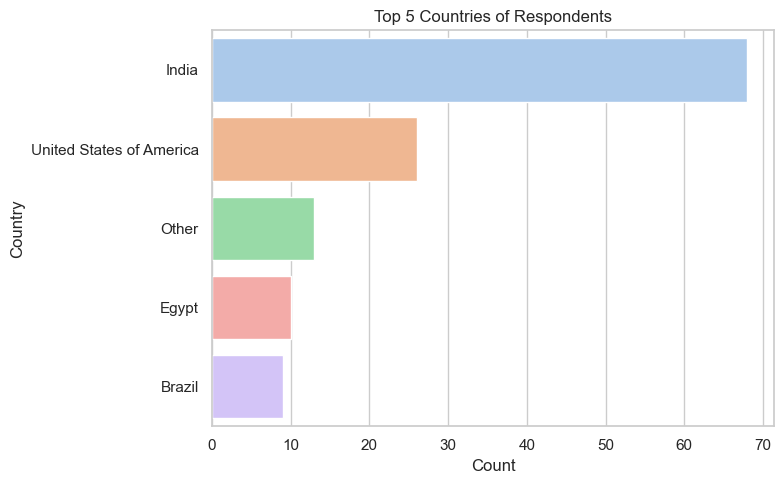

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_countries, x="Count", y="Country")
plt.title("Top 5 Countries of Respondents")
plt.tight_layout()
plt.show()

### Top 5 Job Titles

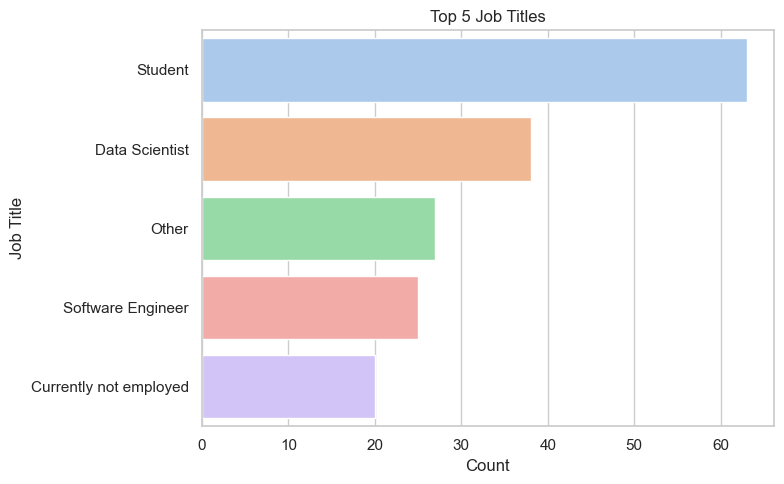

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_jobs, x="Count", y="Job Title")
plt.title("Top 5 Job Titles")
plt.tight_layout()
plt.show()

### Top 5 Programming Languages

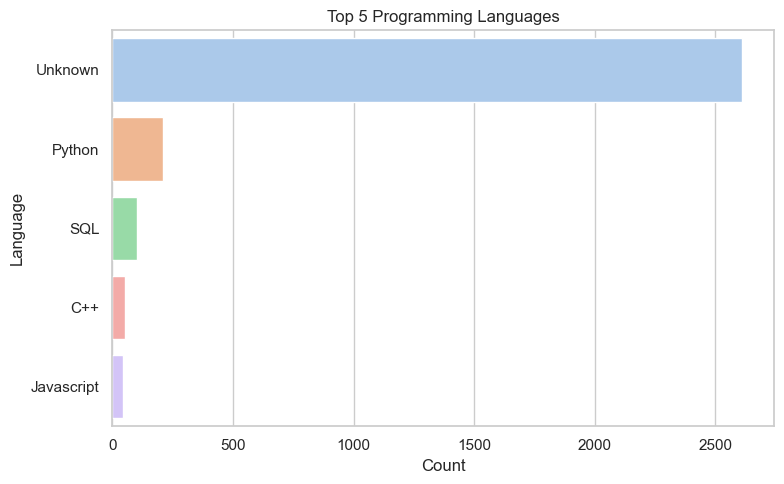

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_languages, x="Count", y="Language")
plt.title("Top 5 Programming Languages")
plt.tight_layout()
plt.show()

### Experience Distribution

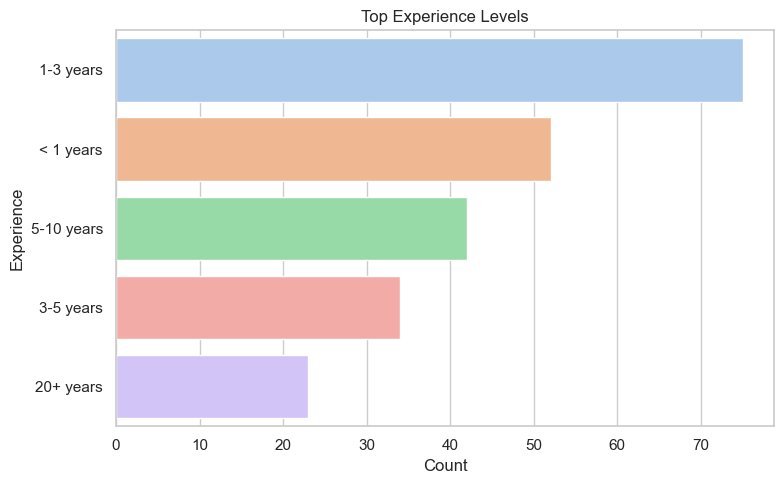

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_experience, x="Count", y="Experience")
plt.title("Top Experience Levels")
plt.tight_layout()
plt.show()

### Salary Distribution

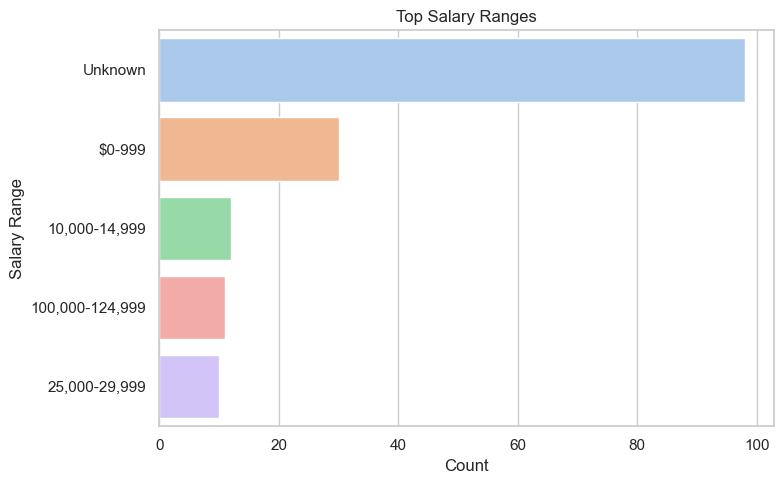

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_salary, x="Count", y="Salary Range")
plt.title("Top Salary Ranges")
plt.tight_layout()
plt.show()